In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

import optuna

In [279]:
train_data = pd.read_parquet('train.parquet')
train_data.sort_values(by='order_create_time', inplace=True, ignore_index=True)
test_data = pd.read_parquet('test.parquet')

In [280]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104595 entries, 0 to 104594
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   target             104595 non-null  int64         
 1   order_create_time  104595 non-null  datetime64[ns]
 2   session_end_time   103971 non-null  datetime64[ns]
 3   model_1            104595 non-null  float64       
 4   model_2            104595 non-null  float64       
 5   model_3            104595 non-null  float64       
 6   model_4            104595 non-null  int64         
 7   model_5            104595 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(2)
memory usage: 6.4 MB


In [281]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17196 entries, 0 to 17195
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           17196 non-null  int64         
 1   order_create_time  17196 non-null  datetime64[ns]
 2   session_end_time   17041 non-null  datetime64[ns]
 3   model_1            17196 non-null  float64       
 4   model_2            17196 non-null  float64       
 5   model_3            17196 non-null  float64       
 6   model_4            17196 non-null  int64         
 7   model_5            17196 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(2)
memory usage: 1.0 MB


In [282]:
train_data

,target,order_create_time,session_end_time,model_1,model_2,model_3,model_4,model_5
0,0,1975-11-01 09:00:05,1975-11-01 08:56:30.137,-1.710108,0.203183,0.039653,1,0.425677
1,0,1975-11-01 09:09:56,1975-11-01 09:26:18.050,-0.573826,0.220081,0.021042,0,0.176025
2,0,1975-11-01 09:10:58,1975-11-01 09:04:20.840,-1.710108,0.203183,0.043441,0,0.422862
3,0,1975-11-01 09:14:53,1975-11-01 09:26:18.050,-0.573826,0.220081,0.021154,0,0.178161
4,0,1975-11-01 09:15:47,1975-10-31 08:44:17.343,-0.482605,0.644805,0.084048,0,0.416131
...,...,...,...,...,...,...,...,...
104590,0,1976-01-31 20:54:25,1976-01-31 21:00:02.087,-0.573826,0.220081,0.020591,0,0.172966
104591,0,1976-01-31 20:54:31,1976-01-31 20:55:02.937,-0.573826,0.220081,0.020448,0,0.167923
104592,0,1976-01-31 20:55:43,1976-01-31 20:58:27.917,-0.573826,0.220081,0.020520,0,0.168175
104593,0,1976-01-31 20:56:03,1976-01-31 20:49:23.113,-1.710108,0.203183,0.045307,0,0.454186


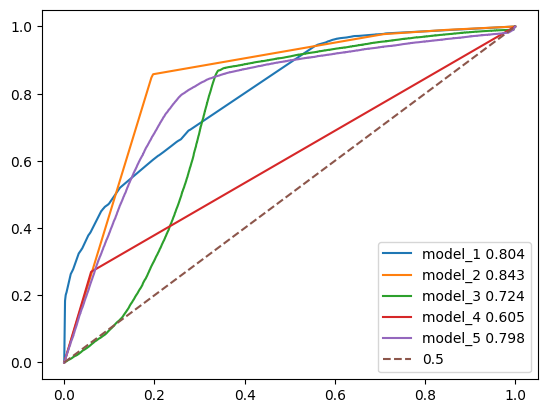

In [283]:
for i in range(1, 6):
    fpr, tpr, thresholds = roc_curve(train_data['target'], train_data[f'model_{i}'])
    roc_auc = roc_auc_score(train_data['target'], train_data[f'model_{i}'])
    plt.plot(fpr, tpr, label=f'model_{i} {round(roc_auc, 3)}')

plt.plot([0, 1], [0, 1], linestyle='--', label='0.5')

plt.legend()
plt.show()

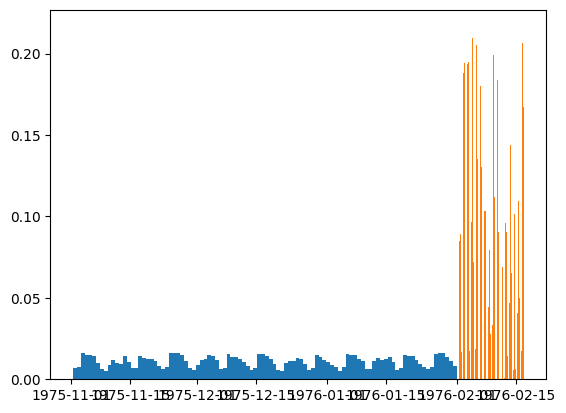

In [284]:
plt.hist(train_data['order_create_time'], bins=100, density=True)
plt.hist(test_data['order_create_time'], bins=100, density=True)
plt.show()

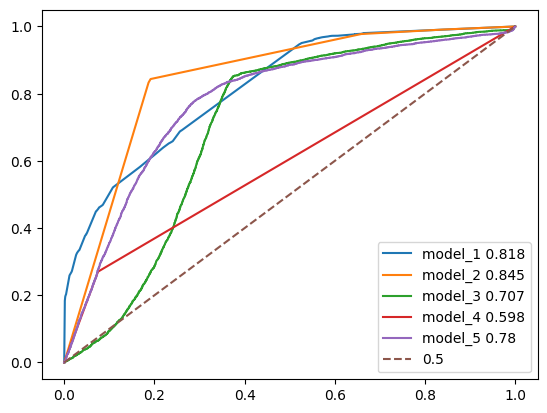

In [285]:
for i in range(1, 6):
    fpr, tpr, thresholds = roc_curve(train_data.iloc[:20000]['target'], train_data.iloc[:20000][f'model_{i}'])
    roc_auc = roc_auc_score(train_data.iloc[:20000]['target'], train_data.iloc[:20000][f'model_{i}'])
    plt.plot(fpr, tpr, label=f'model_{i} {round(roc_auc, 3)}')

plt.plot([0, 1], [0, 1], linestyle='--', label='0.5')

plt.legend()
plt.show()

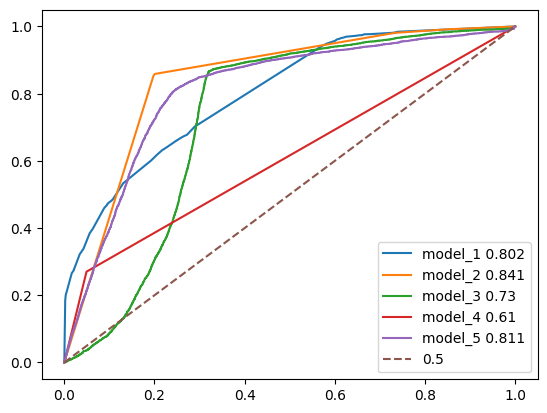

In [286]:
for i in range(1, 6):
    fpr, tpr, thresholds = roc_curve(train_data.iloc[-20000:]['target'], train_data.iloc[-20000:][f'model_{i}'])
    roc_auc = roc_auc_score(train_data.iloc[-20000:]['target'], train_data.iloc[-20000:][f'model_{i}'])
    plt.plot(fpr, tpr, label=f'model_{i} {round(roc_auc, 3)}')

plt.plot([0, 1], [0, 1], linestyle='--', label='0.5')

plt.legend()
plt.show()

In [287]:
for i in range(0, 5):
    mins = train_data[f'model_{i+1}'].min()
    maxs = train_data[f'model_{i+1}'].max()
    train_data[f'model_{i+1}'] = (train_data[f'model_{i+1}'] - mins) / (maxs - mins)

    mins = test_data[f'model_{i+1}'].min()
    maxs = test_data[f'model_{i+1}'].max()
    test_data[f'model_{i+1}'] = (test_data[f'model_{i+1}'] - mins) / (maxs - mins)

In [288]:
train_data['is_end_nan'] = train_data['session_end_time'].isna().astype(int)
train_data['is_before'] = (train_data['order_create_time'] < train_data['session_end_time']).astype(int)
test_data['is_end_nan'] = test_data['session_end_time'].isna().astype(int)
test_data['is_before'] = (test_data['order_create_time'] < test_data['session_end_time']).astype(int)

In [289]:
train_data['mean'] = (train_data['model_1'] + train_data['model_2'] + train_data['model_3'] + train_data['model_4'] + train_data['model_5']) / 5
test_data['mean'] = (test_data['model_1'] + test_data['model_2'] + test_data['model_3'] + test_data['model_4'] + test_data['model_5']) / 5

In [290]:
for i in range(5):
    if i == 3:
        continue
    train_data[f'position_{i+1}'] = np.argsort(np.argsort(train_data[f'model_{i+1}']))
    test_data[f'position_{i+1}'] = np.argsort(np.argsort(test_data[f'model_{i+1}']))

for i in range(5):
    if i == 3:
        continue
    mins = train_data[f'position_{i+1}'].min()
    maxs = train_data[f'position_{i+1}'].max()
    train_data[f'position_{i+1}'] = (train_data[f'position_{i+1}'] - mins) / (maxs - mins)

    mins = test_data[f'position_{i+1}'].min()
    maxs = test_data[f'position_{i+1}'].max()
    test_data[f'position_{i+1}'] = (test_data[f'position_{i+1}'] - mins) / (maxs - mins)

In [291]:
y = train_data['target'].values
X = train_data.drop(['order_create_time', 'session_end_time', 'target'], axis=1)

In [292]:
X_train, y_train = X.iloc[:-20000], y[:-20000]
X_test, y_test = X.iloc[-20000:], y[-20000:]

In [272]:
def objective(trial):
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    C = trial.suggest_float('C', 1e-5, 1e2, log='True')
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    
    logreg = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=1000)
    logreg.fit(X_train, y_train)
    
    predicts = logreg.predict_proba(X_test)[:, 1]
    # Return the mean accuracy
    return roc_auc_score(y_test, predicts)

In [273]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=1)

print("Best trial:")
trial = study.best_trial

print(f"  Roc Auc: {trial.value:.4f}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-05-26 20:42:56,527] A new study created in memory with name: no-name-265e130e-fc63-4b89-a0e8-96593f0acb29
[I 2025-05-26 20:42:56,650] Trial 0 finished with value: 0.8938754119937685 and parameters: {'penalty': 'l2', 'C': 2.510290950074462}. Best is trial 0 with value: 0.8938754119937685.
[I 2025-05-26 20:42:56,937] Trial 1 finished with value: 0.8928535751215743 and parameters: {'penalty': 'l1', 'C': 0.006223818170289221}. Best is trial 0 with value: 0.8938754119937685.
[I 2025-05-26 20:42:57,019] Trial 2 finished with value: 0.8938589845535501 and parameters: {'penalty': 'l2', 'C': 0.1913638769109171}. Best is trial 0 with value: 0.8938754119937685.
[I 2025-05-26 20:42:57,282] Trial 3 finished with value: 0.8912044900850267 and parameters: {'penalty': 'l1', 'C': 0.0039484354817602}. Best is trial 0 with value: 0.8938754119937685.
[I 2025-05-26 20:42:57,349] Trial 4 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 7.073810783074603e-05}. Best is trial 0 with valu

Best trial:
  Roc Auc: 0.8939
  Params:
    penalty: l1
    C: 19.049682339780897


In [274]:
logreg = LogisticRegression(penalty=trial.params['penalty'], C=trial.params['C'], solver='liblinear' if trial.params['penalty'] == 'l1' else 'lbfgs', max_iter=1000)

In [275]:
logreg.fit(X, y)

LogisticRegression(C=19.049682339780897, max_iter=1000, penalty='l1',
                   solver='liblinear')

In [ ]:
predictions = logreg.predict_proba(test_data.drop(['order_create_time', 'session_end_time', 'order_id'], axis=1))[:, 1]
subm = pd.DataFrame(data=np.array([test_data['order_id'], predictions]).T, columns=['order_id', 'is_callcenter'])
subm['order_id'] = subm['order_id'].astype(int)

subm.to_csv('subm6.csv', index=None)

In [297]:
train_data = lgb.Dataset(X_train, label=y_train)

def objective_lgb(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 4, 31),  # small leaves for simple trees
        'max_depth': trial.suggest_int('max_depth', 2, 6),     # shallow trees
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log='True'),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'feature_pre_filter':False,
        'seed': 42,
        'verbose': -1,
        'num_boost_round': trial.suggest_int('num_boost', 5, 200),
    }


    gbm = lgb.train(
        param,
        train_data
    )

    preds = gbm.predict(X_test)

    return roc_auc_score(y_test, preds)

In [298]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgb, n_trials=50)

print("Best trial:")
trial = study.best_trial

print(f"  Roc AUC: {trial.value:.4f}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-05-26 20:48:11,553] A new study created in memory with name: no-name-6427937a-452e-4ee9-9d87-4da986fb80af
[I 2025-05-26 20:48:11,872] Trial 0 finished with value: 0.932612966742084 and parameters: {'num_leaves': 6, 'max_depth': 5, 'learning_rate': 0.005996159466101131, 'min_data_in_leaf': 22, 'feature_fraction': 0.7392007002105571, 'num_boost': 123}. Best is trial 0 with value: 0.932612966742084.
[I 2025-05-26 20:48:12,039] Trial 1 finished with value: 0.9375716003870683 and parameters: {'num_leaves': 12, 'max_depth': 3, 'learning_rate': 0.026359774767808517, 'min_data_in_leaf': 48, 'feature_fraction': 0.623474035724242, 'num_boost': 113}. Best is trial 1 with value: 0.9375716003870683.
[I 2025-05-26 20:48:12,231] Trial 2 finished with value: 0.9393945111926366 and parameters: {'num_leaves': 11, 'max_depth': 6, 'learning_rate': 0.0037824964415886743, 'min_data_in_leaf': 33, 'feature_fraction': 0.9382800871407652, 'num_boost': 89}. Best is trial 2 with value: 0.9393945111926366.

Best trial:
  Roc AUC: 0.9486
  Params:
    num_leaves: 26
    max_depth: 6
    learning_rate: 0.057867938831201476
    min_data_in_leaf: 6
    feature_fraction: 0.7832215468961913
    num_boost: 189


In [300]:
trial.params

{'num_leaves': 26,
 'max_depth': 6,
 'learning_rate': 0.057867938831201476,
 'min_data_in_leaf': 6,
 'feature_fraction': 0.7832215468961913,
 'num_boost': 189}

In [311]:
param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'num_leaves': 10,  # small leaves for simple trees
        'max_depth': trial.params['max_depth'],     # shallow trees
        'learning_rate': trial.params['learning_rate'],
        'min_data_in_leaf': trial.params['min_data_in_leaf'],
        'feature_fraction': trial.params['feature_fraction'],
        'feature_pre_filter':False,
        'seed': 42,
        'verbose': -1,
        'num_boost_round': 200,
    }

train_data = lgb.Dataset(X, label=y)
gbm = lgb.train(
    param,
    train_data
)

In [312]:
preds = gbm.predict(test_data.drop(['order_create_time', 'session_end_time', 'order_id'], axis=1))
subm = pd.DataFrame(data=np.array([test_data['order_id'], preds]).T, columns=['order_id', 'is_callcenter'])
subm['order_id'] = subm['order_id'].astype(int)

subm.to_csv('subm10.csv', index=None)